# Figure 07 -- single-GPU vs CPU speedup

Loads `results/scaling/gpu_vs_cpu.json`, produced by `bench/scaling/gpu_vs_cpu_speedup.py`. No computation here.

In [1]:
import pathlib, sys
sys.path.insert(0, str(pathlib.Path.cwd().parents[1] if pathlib.Path.cwd().name == "jaccpot_paper" else pathlib.Path.cwd()))

import numpy as np
import matplotlib.pyplot as plt

from examples.jaccpot_paper.common import jsonio, style

style.apply()
FIG_DIR = jsonio.repo_root() / "results" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)


not measured: [(1048576, 'RESOURCE_EXHAUSTED: Out of memory while trying to allocate 4')]


wrote /export/home/tbuck/jaccpot-paper-wt/results/figures/fig07_gpu_vs_cpu.pdf
measured on a shared 72-core / 8-GPU host; the CPU arm is not a dedicated-machine measurement and the ratio is indicative


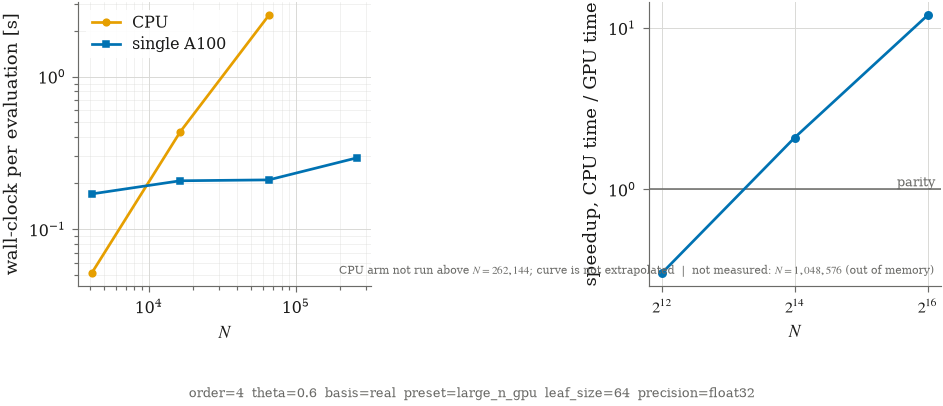

In [2]:
art = jsonio.read_result("scaling/gpu_vs_cpu.json")
cfg, recs = art["config"], art["data"]["records"]
recs = sorted(recs, key=lambda r: r["n"])

fig, axes = style.figure(width=style.TWO_COL, height=2.7, ncols=2)

# Left: the two raw curves, so the ratio on the right is auditable.
ax = axes[0]
for i, (key, label, entity) in enumerate(
    (("cpu_min_s", "CPU", "cpu"), ("gpu_min_s", "single A100", "gpu"))
):
    sel = [r for r in recs if r.get(key)]
    if not sel:
        continue
    ax.plot(
        [r["n"] for r in sel], [r[key] for r in sel],
        marker=style.MARKERS[i % len(style.MARKERS)],
        color=style.entity_color(entity), label=label, markersize=3.4,
    )
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("$N$"); ax.set_ylabel("wall-clock per evaluation [s]")
style.finish(ax, legend_kwargs={"loc": "upper left"})

# Right: the speedup, only where BOTH arms were measured.
ax = axes[1]
sel = [r for r in recs if r.get("speedup")]
ax.plot(
    [r["n"] for r in sel], [r["speedup"] for r in sel],
    marker="o", color=style.entity_color("gpu"), markersize=3.8,
)
ax.axhline(1.0, color=style.INK_MUTED, linewidth=0.8, zorder=1)
ax.text(0.98, 1.0, " parity", transform=ax.get_yaxis_transform(),
        ha="right", va="bottom", fontsize=6.5, color=style.INK_MUTED)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("$N$"); ax.set_ylabel("speedup, CPU time / GPU time")
style.finish(ax, legend=False)

# With only a few matched points the log minor-tick labels collide into an
# unreadable band, so tick exactly at the measured N.
ticks = [r["n"] for r in sel]
if ticks:
    ax.set_xticks(ticks)
    ax.set_xticklabels([f"$2^{{{int(round(np.log2(n)))}}}$" for n in ticks])
    ax.minorticks_off()

notes = []
skipped = [r["n"] for r in recs if r.get("cpu_skipped")]
if skipped:
    notes.append(
        f"CPU arm not run above $N={min(skipped):,}$; curve is not extrapolated"
    )
# A point that failed is named, not dropped: the alternative is a figure that
# looks like it covered a range it never reached.
failed = [(r["n"], r["gpu_error"]) for r in recs if r.get("gpu_error")]
if failed:
    notes.append(
        "not measured: $N="
        + ", ".join(f"{n:,}" for n, _ in failed)
        + "$ (out of memory)"
    )
    print("not measured:", [(n, e[:60]) for n, e in failed])
if notes:
    ax.text(
        0.98, 0.03, "  |  ".join(notes),
        transform=ax.transAxes, va="bottom", ha="right",
        fontsize=5.6, color=style.INK_MUTED,
    )
fig.tight_layout()
style.footer(
    fig,
    jsonio.config_caption(cfg, ["order", "theta", "basis", "preset", "leaf_size", "precision"]),
)
style.save(fig, FIG_DIR / "fig07_gpu_vs_cpu.pdf")
print(cfg.get("shared_host", ""))


## Caption

Single-GPU against CPU wall-clock (left) and the resulting speedup (right), both
timing the identical quantity -- evaluation on a prebuilt tree at the same $N$,
seed, order, $\theta$, leaf size and precision -- so that only the backend
differs. The GPU curve is nearly flat at small $N$, where the device is launch-
and overhead-bound rather than work-bound, so the speedup crosses unity only once
there is enough work to fill the card. The CPU arm is not run above the annotated
$N$ and the curve is not extrapolated past the last measured pair. Measured on a
shared 72-core host, so the ratio is indicative rather than a hardware review.
Values from `results/scaling/gpu_vs_cpu.json`.
